In [1]:

# Setting up the Environment
# We installed these specific versions for compatibility reasons (The file was made in DeepNote)

%pip install numpy==1.26.4 pandas scikit-learn==1.3.2 shap==0.44.1 matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [1]:
# Imports for handling the data
import pandas as pd
import numpy as np

# Imports used for the Machine Learning
from sklearn.model_selection import train_test_split # To split the data into training and test sets
from sklearn.ensemble import RandomForestClassifier # The model we will analyse for bias
from sklearn.metrics import accuracy_score # This allows us to evaluate the accuracy of our model

# Importing the XAI Method SHAP.
import shap


C:\Users\peter\AppData\Roaming\Python\Python311\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\peter\AppData\Roaming\Python\Python311\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# Gains acces to the file adult.csv by loading it into a pandas DataFrame
df = pd.read_csv("adult.csv") 
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [3]:
# Preprocessing the Data

df.replace("?", np.nan, inplace=True) # We replace the ? mark with a NaN object, and then remove the rows containing them.
df = df.dropna()

df = df.drop(columns=['fnlwgt']) # We remove the 'fnlwgt' column since it not an actual characteristic of the candidates.

# The commented out code below removes certain personal features in order to test the effectiveness of SHAP. And seeing whether this changes the model's performance.
'''
df = df.drop(columns=['relationship'])
df = df.drop(columns=['marital-status'])
df = df.drop(columns=['gender'])
df = df.drop(columns=['race'])
df = df.drop(columns=['age'])
df = df.drop(columns=['native-country'])
'''

y = df["income"].apply(lambda x: 1 if x == '>50K' else 0) # We define our target as this income label (0 for <=50k, 1 for >50k)
X = df.drop("income", axis=1) # We drop the income column because we want the model to use all other variables to predict it.

# This converts all categorical text into separate binary columns. (1 or 0)
# For Gender, this would become a column with gender_Male, and gender_Female. Which is necessary for Random Forest.
# One-Hot Encoding
X = pd.get_dummies(X, drop_first=True)

In [4]:
# We split the data into 80% training, and 20% testing.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [5]:
# We train the Random Forest Model using the training data.
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# We let the model predict the income of our test data and calculate the accuracy to ensure our model is effective.
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8386954118297402


In [ ]:
# We calculate SHAP values. We take a sample of 300 instances because it is computationally expensive to calculate over the entire test set.
X_sample = X_test.sample(300, random_state=42)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

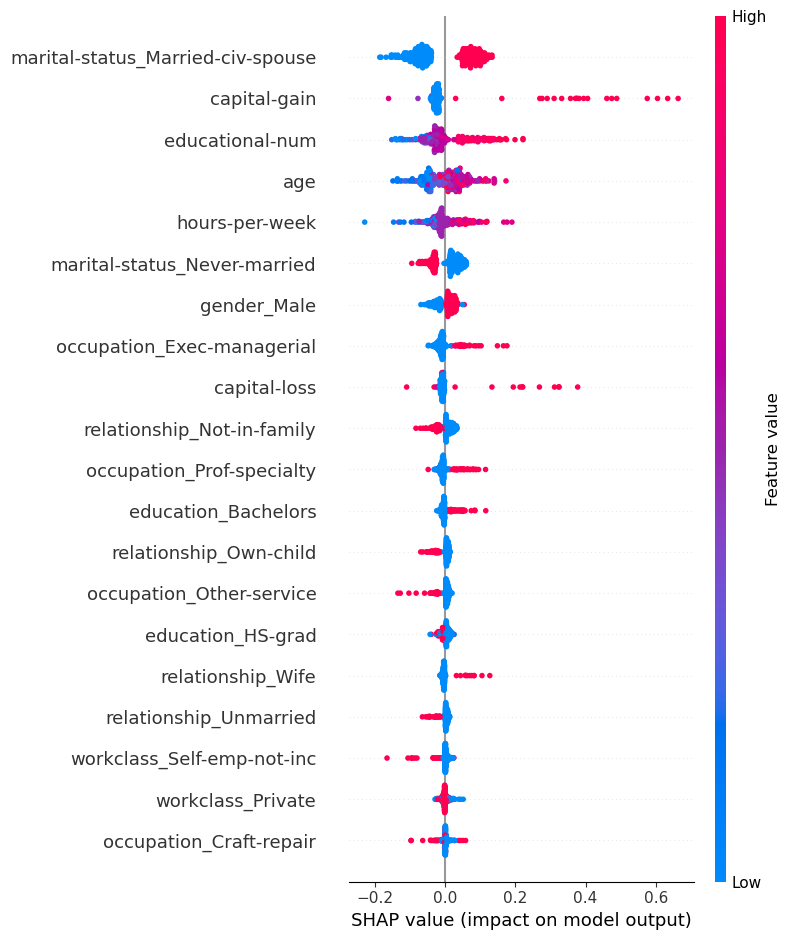

In [ ]:
# We plot the summary plot. containing the feature importance over the data.
# Feature importance is ranked from high to low by impact.
shap.summary_plot(shap_values[1], X_sample)

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=2a4fae61-7c6d-4f44-aaa3-bddc3bc318f1' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>